In [ ]:
# install pyspark
# Python library for working with Apache Spark

!pip install pyspark

In [ ]:
# imports SparkSession from PySpark

from pyspark.sql import SparkSession

In [ ]:
# Iris Classification using Spark MLlib
# load the Iris dataset
# the dataset contains 4 features (sepal length, sepal width, petal length and petal width) and 1 target (species)

In [ ]:
# show the table

spark = SparkSession.builder.appName("IrisClassification").getOrCreate()

df = spark.read.csv("iris.csv", header=True, inferSchema=True)

df.show(10)

+------------+-----------+------------+-----------+-------+
|sepal_length|sepal_width|petal_length|petal_width|species|
+------------+-----------+------------+-----------+-------+
|         5.1|        3.5|         1.4|        0.2| setosa|
|         4.9|        3.0|         1.4|        0.2| setosa|
|         4.7|        3.2|         1.3|        0.2| setosa|
|         4.6|        3.1|         1.5|        0.2| setosa|
|         5.0|        3.6|         1.4|        0.2| setosa|
|         5.4|        3.9|         1.7|        0.4| setosa|
|         4.6|        3.4|         1.4|        0.3| setosa|
|         5.0|        3.4|         1.5|        0.2| setosa|
|         4.4|        2.9|         1.4|        0.2| setosa|
|         4.9|        3.1|         1.5|        0.1| setosa|
+------------+-----------+------------+-----------+-------+
only showing top 10 rows


### Preprocess data

In [ ]:
# data preprocessing
# imports col function from PySpark
# col is to refer to dataframe column

from pyspark.sql.functions import col

In [ ]:
# find duplicates
# group all col together and count how many times each row appear
# if more than 1, consider a duplicate

df_duplicates = df.groupBy(df.columns).count().filter(col("count") > 1)
df_duplicates.show()

+------------+-----------+------------+-----------+---------+-----+
|sepal_length|sepal_width|petal_length|petal_width|  species|count|
+------------+-----------+------------+-----------+---------+-----+
|         4.9|        3.1|         1.5|        0.1|   setosa|    3|
|         5.8|        2.7|         5.1|        1.9|virginica|    2|
+------------+-----------+------------+-----------+---------+-----+



The duplicate check identified two duplicated records in the dataset. One setosa observation appears three times, while one virginica observation appears twice. These duplicated records should be reviewed to determine whether they are genuine repeated observations or unintended duplicates. If they are accidental duplicates, they should be removed before further analysis to avoid introducing bias into the results.

In [ ]:
# drop the duplicate
# the cleaned dataset is set as df_clean

df_clean = df.dropDuplicates()
df_clean.show()

+------------+-----------+------------+-----------+----------+
|sepal_length|sepal_width|petal_length|petal_width|   species|
+------------+-----------+------------+-----------+----------+
|         5.1|        3.5|         1.4|        0.3|    setosa|
|         5.0|        3.4|         1.6|        0.4|    setosa|
|         4.4|        3.2|         1.3|        0.2|    setosa|
|         4.8|        3.4|         1.6|        0.2|    setosa|
|         5.0|        3.3|         1.4|        0.2|    setosa|
|         6.3|        2.5|         5.0|        1.9| virginica|
|         4.5|        2.3|         1.3|        0.3|    setosa|
|         5.8|        4.0|         1.2|        0.2|    setosa|
|         5.8|        2.7|         3.9|        1.2|versicolor|
|         6.8|        3.0|         5.5|        2.1| virginica|
|         6.0|        2.2|         5.0|        1.5| virginica|
|         4.8|        3.0|         1.4|        0.3|    setosa|
|         5.1|        3.8|         1.6|        0.2|    

The duplicate records have been successfully removed from the dataset using the dropDuplicates() function. The resulting dataset, stored as df_clean, contains only unique observations and is ready for further data preprocessing and analysis. This ensures that duplicate do not influence the results of subsequent analyses.

In [ ]:
# check again to make sure duplicates have been remove

df_clean.groupBy(df_clean.columns).count().filter("count > 1").show()

+------------+-----------+------------+-----------+-------+-----+
|sepal_length|sepal_width|petal_length|petal_width|species|count|
+------------+-----------+------------+-----------+-------+-----+
+------------+-----------+------------+-----------+-------+-----+



The duplicate verification returned no records, indicating that all duplicate entries have been successfully removed from the dataset. The cleaned dataset now contains only unique observations and is ready for further preprocessing and analysis.

In [ ]:
# to count total value such as missing values or sum column
# import function sum

from pyspark.sql.functions import sum

In [ ]:
# to check if theres any null value in the data

df_clean.select([sum(col(c).isNull().cast("int")).alias(c) for c in df_clean.columns]).show()

+------------+-----------+------------+-----------+-------+
|sepal_length|sepal_width|petal_length|petal_width|species|
+------------+-----------+------------+-----------+-------+
|           0|          0|           0|          0|      0|
+------------+-----------+------------+-----------+-------+



The results show that all columns contain 0 missing values, indicating that the dataset is complete and does not require any additional handling for missing data. Since there are no null values, the dataset is ready for the next stage of preprocessing or analysis.

In [ ]:
# display dataset structure
# data types

df_clean.printSchema()

root
 |-- sepal_length: double (nullable = true)
 |-- sepal_width: double (nullable = true)
 |-- petal_length: double (nullable = true)
 |-- petal_width: double (nullable = true)
 |-- species: string (nullable = true)



The dataset consists of five columns. 4 numerical features (sepal_length, sepal_width, petal_length, and petal_width) stored as double data types, and 1 categorical variable (species) stored as a string data type. The numerical columns can be directly used for statistical analysis, while the species column may require transformation, such as label encoding, before being used in machine learning algorithms.

In [ ]:
# compare original data and cleaned data

print("Original:", df.count())
print("Cleaned:", df_clean.count())

Original: 150
Cleaned: 147


The original dataset contains 150 records, while the cleaned dataset contains 147 records after duplicate removal. This indicates that 3 duplicate records were identified and removed during the data cleaning process. The reduction in dataset size is expected because duplicate observations do not provide additional information and may affect the reliability of further analysis.

In [ ]:
# create label
# convert column (species) to numerical values
# important because ML in Spark MLlib only works with numerical data
# So the result is stored in new column named 'label'

from pyspark.ml.feature import StringIndexer

indexer = StringIndexer(inputCol="species", outputCol="label")
df_clean = indexer.fit(df_clean).transform(df_clean)

The species column has been successfully transformed into a numerical label column. Each unique species category is assigned a corresponding numerical value, allowing the dataset to be processed by Spark MLlib algorithms. The original species column is retained for reference, while the new label column will be used during model training.

In [ ]:
#verify the transformation
df_clean.select("species", "label").distinct().show()

+----------+-----+
|   species|label|
+----------+-----+
|versicolor|  0.0|
|    setosa|  2.0|
| virginica|  1.0|
+----------+-----+



The output confirms that each species category has been mapped to a unique numerical label. This transformation prepares the categorical target variable for machine learning classification tasks.

In [ ]:
# create features
# combine input column into one feature vector
# take numeric columns (sepal length, width etc) and merge into 1 column named 'features'
# this is important because Spark can process all input all together

from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(
    inputCols=["sepal_length", "sepal_width", "petal_length", "petal_width"],
    outputCol="features"
)

df_clean = assembler.transform(df_clean)

The numerical feature columns have been successfully combined into a single features column. The new column contains a vector of the four input variables required by Spark MLlib algorithms. This transformation allows machine learning models to process all predictor variables together during the training and prediction stages.

In [ ]:
#verify the transformation|
df_clean.select("features", "label").show(5, truncate=False)

+-----------------+-----+
|features         |label|
+-----------------+-----+
|[5.1,3.5,1.4,0.3]|2.0  |
|[5.0,3.4,1.6,0.4]|2.0  |
|[4.4,3.2,1.3,0.2]|2.0  |
|[4.8,3.4,1.6,0.2]|2.0  |
|[5.0,3.3,1.4,0.2]|2.0  |
+-----------------+-----+
only showing top 5 rows


The features column contains the four numerical attributes combined into a single vector, while the label column represents the encoded target class. The dataset is now in the required format for Spark MLlib classification models.

#### split dataset

In [ ]:
# splits the dataset into two parts
# training data and testing data
# 80% of the data is used to train the machine learning model
# 20% is used to test its performance

train_data, test_data = df_clean.randomSplit([0.8, 0.2], seed=42)

In [ ]:
# verify split ratio and make sure data is divided properly

print("Training data:", train_data.count())
print("Testing data:", test_data.count())

Training data: 123
Testing data: 24


The dataset has been successfully divided into two subsets. 123 records for training and 24 records for testing. The training set contains approximately 84% of the data, while the testing set contains approximately 16% of the data. The slight difference from the intended 80:20 ratio is due to the random splitting process, which may not always produce an exact proportion.

The training dataset will be used to train the machine learning models while the testing dataset will be used to evaluate model performance on unseen data.

**Setting Up Model Evaluation Metric**

After training machine learning models, the model performance needs to be evaluated using appropriate evaluation metrics. Since this is a multiclass classification problem (predicting multiple species categories), the MulticlassClassificationEvaluator from Spark MLlib is used.

The evaluator compares the actual class labels (label) with the predicted labels (prediction) generated by the model. This evaluator will be used to measure the performance of different classification models using metrics such as accuracy, precision, recall, and F1-score.

In [ ]:
# EVALUATOR (COMMON)
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction"
)

**Decision Tree Classification Model with Cross-Validation**

A Decision Tree classifier is applied to predict the species category based on the four numerical features: sepal_length, sepal_width, petal_length, and petal_width. The features column is used as the input variable, while the label column is used as the target output.

To improve model performance, Grid Search with Cross-Validation is performed. Different combinations of model parameters (maxDepth and maxBins) are tested to identify the best-performing model configuration. A 3-fold cross-validation method is used, where the training data is divided into three subsets and the model is evaluated multiple times to reduce the effect of data variation.

The best model obtained from cross-validation is then used to generate predictions on the unseen test dataset.

In [ ]:
# apply decision tree model
# created using feature as input and label as target output
# The model is trained using train_data
# after training, transform() is used to generate predictions on the test dataset

from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder

dt = DecisionTreeClassifier(featuresCol="features", labelCol="label")

# Grid search
paramGrid_dt = ParamGridBuilder() \
    .addGrid(dt.maxDepth, [3, 5, 10]) \
    .addGrid(dt.maxBins, [16, 32]) \
    .build()

#Cross validation
crossval_dt = CrossValidator(
    estimator=dt,
    estimatorParamMaps=paramGrid_dt,
    evaluator=evaluator,
    numFolds=3
)

dt_model = crossval_dt.fit(train_data)
dt_predictions = dt_model.transform(test_data)

**Random Forest Classification Model with Cross-Validation**

A Random Forest classifier is implemented to predict the species category using the input features stored in the features column and the target variable stored in the label column.

Random Forest is an ensemble learning method that combines multiple Decision Trees to improve prediction performance and reduce overfitting. Instead of relying on a single tree, multiple trees are trained using different subsets of the data and their predictions are combined to produce the final classification result.

To optimize the model performance, Grid Search with 3-fold Cross-Validation is applied. Different values of numTrees and maxDepth are tested to identify the best parameter combination. The optimized Random Forest model is then used to predict species labels from the test dataset.

In [ ]:
from pyspark.ml.classification import RandomForestClassifier

rf = RandomForestClassifier(featuresCol="features", labelCol="label")

# Grid search
paramGrid_rf = ParamGridBuilder() \
    .addGrid(rf.numTrees, [10, 20, 50]) \
    .addGrid(rf.maxDepth, [5, 10]) \
    .build()

#Cross validation
crossval_rf = CrossValidator(
    estimator=rf,
    estimatorParamMaps=paramGrid_rf,
    evaluator=evaluator,
    numFolds=3
)

rf_model = crossval_rf.fit(train_data)
rf_predictions = rf_model.transform(test_data)

**Logistic Regression Classification Model with Cross-Validation**

A Logistic Regression classifier is applied to predict the species category using the numerical feature vector stored in the features column and the target variable stored in the label column.

Although Logistic Regression is commonly used for binary classification, Spark MLlib extends it to support multiclass classification using a one-vs-rest approach. In this approach, multiple binary classifiers are created to distinguish between different species categories.

To improve model performance, Grid Search with 3-fold Cross-Validation is performed. Different combinations of regularization parameters (regParam) and Elastic Net parameters (elasticNetParam) are tested to identify the best model configuration. The optimized Logistic Regression model is then used to generate predictions on the test dataset.

In [ ]:
from pyspark.ml.classification import LogisticRegression

lr = LogisticRegression(featuresCol="features", labelCol="label")

# Grid search
paramGrid_lr = ParamGridBuilder() \
    .addGrid(lr.regParam, [0.01, 0.1, 0.5]) \
    .addGrid(lr.elasticNetParam, [0.0, 0.5, 1.0]) \
    .build()

# Cross validation
crossval_lr = CrossValidator(
    estimator=lr,
    estimatorParamMaps=paramGrid_lr,
    evaluator=evaluator,
    numFolds=3
)

lr_model = crossval_lr.fit(train_data)
lr_predictions = lr_model.transform(test_data)

**Creating Model Evaluation Function**

After training the classification models, their performance needs to be evaluated using several classification metrics. A reusable function is created to calculate and display the performance of each model using accuracy, precision, recall, and F1-score.

Creating a function avoids repeating the same evaluation code for each model and ensures that all models are evaluated using the same criteria, allowing fair comparison between different machine learning algorithms.

In [ ]:
# create a function to evaluate each method

def evaluate_model(pred, name):
    print("\n", name)
    print("Accuracy:", evaluator.setMetricName("accuracy").evaluate(pred))
    print("Precision:", evaluator.setMetricName("weightedPrecision").evaluate(pred))
    print("Recall:", evaluator.setMetricName("weightedRecall").evaluate(pred))
    print("F1 Score:", evaluator.setMetricName("f1").evaluate(pred))

The evaluation function has been successfully created. The function takes two inputs: the prediction results generated by each model (pred) and the model name (name). It calculates four performance metrics:

Accuracy: Measures the overall percentage of correct predictions.

Precision: Measures how accurately the model predicts each class.

Recall: Measures the ability of the model to correctly identify actual classes.

F1-score: Provides a balance between precision and recall.

This function will be applied to the prediction results from each classification model to compare their performance.

**Comparing Classification Model Performance**

The performance of the three tuned classification models is compared using the evaluation function created earlier. The models evaluated are Decision Tree, Random Forest, and Logistic Regression.

The comparison is based on four evaluation metrics: accuracy, precision, recall, and F1-score. These metrics provide an overall assessment of how well each model can correctly classify the Iris flower species.

In [ ]:
# final comparison between the 3 method

evaluate_model(dt_predictions, "Decision Tree (Tuned)")
evaluate_model(rf_predictions, "Random Forest (Tuned)")
evaluate_model(lr_predictions, "Logistic Regression (Tuned)")


 Decision Tree (Tuned)
Accuracy: 0.9583333333333334
Precision: 0.9642857142857143
Recall: 0.9583333333333334
F1 Score: 0.956959706959707

 Random Forest (Tuned)
Accuracy: 0.9583333333333334
Precision: 0.9642857142857143
Recall: 0.9583333333333334
F1 Score: 0.956959706959707

 Logistic Regression (Tuned)
Accuracy: 0.9583333333333334
Precision: 0.9642857142857143
Recall: 0.9583333333333334
F1 Score: 0.956959706959707


All models correctly classified approximately 95.83% of the test observations. The precision value of 96.43% indicates that most predicted classes were correct, while the recall value of 95.83% shows that the models successfully identified most actual classes. The F1-score of 95.70% indicates a good balance between precision and recall.

Since all three models produced identical evaluation scores, no single model demonstrated superior performance on this dataset. Therefore, model selection may depend on other factors such as interpretability, computational efficiency, and model complexity.

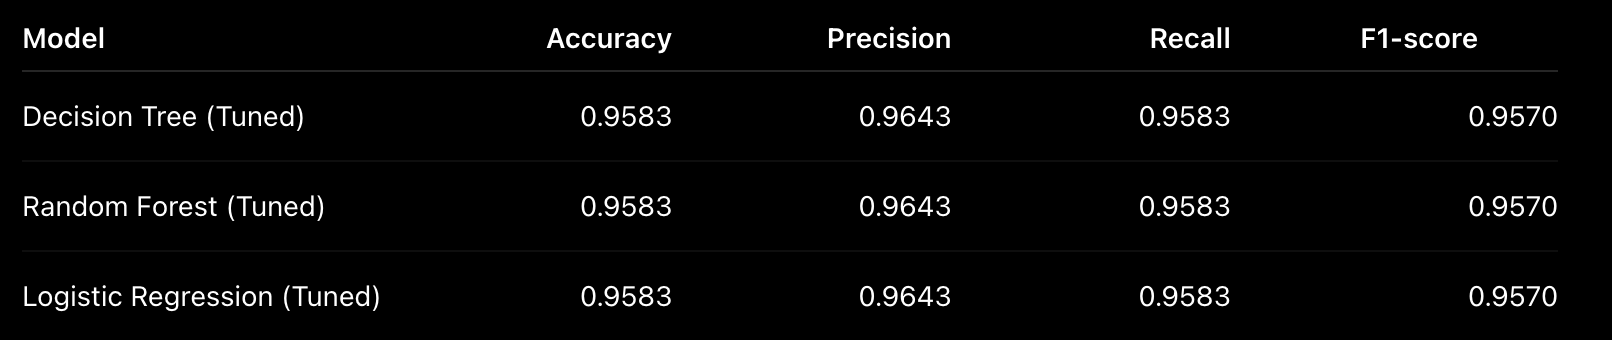

In conclusion, the Iris dataset was successfully processed and classified using three tuned Spark MLlib algorithms which are Decision Tree, Random Forest, and Logistic Regression. All models achieved 95.83% accuracy, indicating strong classification performance. Although no model outperformed the others, Random Forest can be considered a suitable model due to its robustness, while Decision Tree provides better interpretability. The choice of model depends on the specific requirements of accuracy, interpretability, and computational efficiency.

**Best Parameters of all 3 model**

In [ ]:
# Best Decision Tree parameters

best_dt = dt_model.bestModel

print("Best Decision Tree Parameters")
print("maxDepth:", best_dt.getMaxDepth())
print("maxBins:", best_dt.getMaxBins())

Best Decision Tree Parameters
maxDepth: 5
maxBins: 32


In [ ]:
# Best Random Forest parameters

best_rf = rf_model.bestModel

print("Best Random Forest Parameters")
print("numTrees:", best_rf.getNumTrees)
print("maxDepth:", best_rf.getMaxDepth())

Best Random Forest Parameters
numTrees: 10
maxDepth: 5


In [42]:
# Best Logistic Regression parameters

best_lr = lr_model.bestModel

print("Best Logistic Regression Parameters")
print("regParam:", best_lr.getRegParam())
print("elasticNetParam:", best_lr.getElasticNetParam())

Best Logistic Regression Parameters
regParam: 0.01
elasticNetParam: 0.0


For the Decision Tree model, the best settings were maxDepth = 5 and maxBins = 32. This means the model performed best when the tree was allowed to grow up to 5 levels and used 32 bins when making decisions.

For the Random Forest model, the best settings were numTrees = 10 and maxDepth = 5. This means the model achieved the best performance using 10 decision trees, where each tree had a maximum depth of 5 levels.

For the Logistic Regression model, the best settings were regParam = 0.01 and elasticNetParam = 0.0. This shows that the model performed best with a small regularization value and used L2 regularization to reduce overfitting.

Overall, these parameters were selected by Spark after testing different combinations using grid search and cross-validation. The selected models were then used to make predictions on the testing dataset.

**Additional analysis : confusion matrix**



To further evaluate the classification models, a confusion matrix is generated for each model. Unlike overall evaluation metrics such as accuracy and F1-score, the confusion matrix provides a detailed summary of the classification results by showing the number of correct and incorrect predictions for each class.

This analysis helps identify which Iris species are classified correctly and which species are more likely to be misclassified.

1. Create a function to display the confusion matrix

In [ ]:
def confusion_matrix(predictions, model_name):
    print("\n", "="*50)
    print(model_name)
    print("="*50)

    cm = predictions.groupBy("label", "prediction").count().orderBy("label", "prediction")

    cm.show()

2. Display the confusion matrix for each model

In [ ]:
confusion_matrix(dt_predictions, "Decision Tree")
confusion_matrix(rf_predictions, "Random Forest")
confusion_matrix(lr_predictions, "Logistic Regression")


Decision Tree
+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|  0.0|       0.0|    6|
|  1.0|       0.0|    1|
|  1.0|       1.0|    3|
|  2.0|       2.0|   14|
+-----+----------+-----+


Random Forest
+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|  0.0|       0.0|    6|
|  1.0|       0.0|    1|
|  1.0|       1.0|    3|
|  2.0|       2.0|   14|
+-----+----------+-----+


Logistic Regression
+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|  0.0|       0.0|    6|
|  1.0|       0.0|    1|
|  1.0|       1.0|    3|
|  2.0|       2.0|   14|
+-----+----------+-----+



The confusion matrix shows the classification results of the three models (Decision Tree, Random Forest, and Logistic Regression) on the testing dataset.

There were 24 flower samples in the testing dataset. The models correctly classified 23 samples, while only 1 sample was incorrectly classified.

For versicolor (label 0.0), all 6 samples were correctly predicted as versicolor. This shows that the models were able to identify versicolor flowers accurately.

For virginica (label 1.0), there were 4 samples in the testing dataset. The models correctly classified 3 samples as virginica, but 1 sample was incorrectly classified as versicolor. This indicates that the model had some difficulty distinguishing between virginica and versicolor for one observation.

For setosa (label 2.0), all 14 samples were correctly predicted as setosa. This shows that setosa was the easiest class for the models to identify.

Overall, the confusion matrix shows that all three models produced the same prediction results, with only one misclassification between virginica and versicolor. This is consistent with the evaluation metrics, where all models achieved the same accuracy of 95.83%.

**Additional analysis : Misclassification**

In [ ]:
# Show incorrect predictions

wrong_predictions = dt_predictions.filter(
    col("label") != col("prediction")
)

wrong_predictions.show()

+------------+-----------+------------+-----------+---------+-----+-----------------+--------------+--------------------+----------+
|sepal_length|sepal_width|petal_length|petal_width|  species|label|         features| rawPrediction|         probability|prediction|
+------------+-----------+------------+-----------+---------+-----+-----------------+--------------+--------------------+----------+
|         6.3|        2.8|         5.1|        1.5|virginica|  1.0|[6.3,2.8,5.1,1.5]|[42.0,1.0,0.0]|[0.97674418604651...|       0.0|
+------------+-----------+------------+-----------+---------+-----+-----------------+--------------+--------------------+----------+



The misclassification analysis shows that the model made only one incorrect prediction on the testing dataset. A virginica sample with measurements of sepal length 6.3 cm, sepal width 2.8 cm, petal length 5.1 cm, and petal width 1.5 cm was incorrectly classified as versicolor.

This error may occur because virginica and versicolor have similar characteristics, making them more difficult for the model to distinguish. The model correctly classified the other samples, showing that it was able to identify most Iris species accurately.